# Notebook 1: Exploratory Data Analysis (EDA) & Data Loading

## Objective
1. Load the raw dataset and perform initial data cleaning (removing irrelevant columns).
2. Understand the basic structure, data types, and missing values.
3. Perform Univariate Analysis to check the distribution of the target variable (`Attrition_Flag`).
4. Perform Bivariate Analysis to find relationships between customer features and churn rate.
5. Identify correlations between numerical variables.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
# Make sure to run download_data.py so the file exists in data/raw/
file_path = '../data/raw/BankChurners.csv'
df = pd.read_csv(file_path)

# Drop irrelevant and data-leakage columns
cols_to_drop = [
    'CLIENTNUM',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
]
df = df.drop(columns=cols_to_drop)

print(f"[*] Data successfully loaded and cleaned.")
print(f"[*] Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.")

# Display the first 5 rows
df.head()

[*] Data successfully loaded and cleaned.
[*] Dataset Shape: 10127 rows and 20 columns.


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [3]:
# Check data types and missing values
print("--- Data Information ---")
display(df.info())

print("\n--- Missing Values Check ---")
display(df.isnull().sum())

print("\n--- Statistical Summary of Numerical Features ---")
display(df.describe().T)

--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-

None


--- Missing Values Check ---


Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64


--- Statistical Summary of Numerical Features ---


,count,mean,std,min,25%,50%,75%,max
Customer_Age,10127.0,46.325960,8.016814,26.0,41.000,46.000,52.000,73.000
Dependent_count,10127.0,2.346203,1.298908,0.0,1.000,2.000,3.000,5.000
Months_on_book,10127.0,35.928409,7.986416,13.0,31.000,36.000,40.000,56.000
Total_Relationship_Count,10127.0,3.812580,1.554408,1.0,3.000,4.000,5.000,6.000
Months_Inactive_12_mon,10127.0,2.341167,1.010622,0.0,2.000,2.000,3.000,6.000
Contacts_Count_12_mon,10127.0,2.455317,1.106225,0.0,2.000,2.000,3.000,6.000
Credit_Limit,10127.0,8631.953698,9088.776650,1438.3,2555.000,4549.000,11067.500,34516.000
Total_Revolving_Bal,10127.0,1162.814061,814.987335,0.0,359.000,1276.000,1784.000,2517.000
Avg_Open_To_Buy,10127.0,7469.139637,9090.685324,3.0,1324.500,3474.000,9859.000,34516.000
Total_Amt_Chng_Q4_Q1,10127.0,0.759941,0.219207,0.0,0.631,0.736,0.859,3.397


C:\Users\Admin\AppData\Local\Temp\ipykernel_4436\2956846071.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Attrition_Flag', palette='Set2')


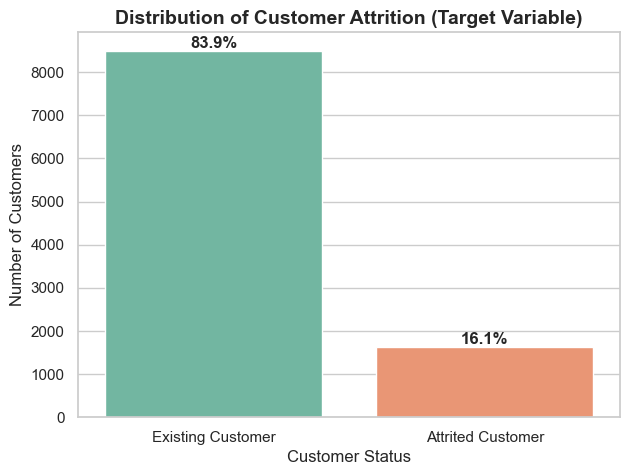

In [ ]:
# Visualize the target variable 'Attrition_Flag'
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='Attrition_Flag', palette='Set2')

plt.title('Distribution of Customer Attrition (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add percentage annotations on top of bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()
# Insight: We can see the dataset is highly imbalanced (with ~16% churned vs ~84% existing). 
# We will need techniques like SMOTE later to handle this.

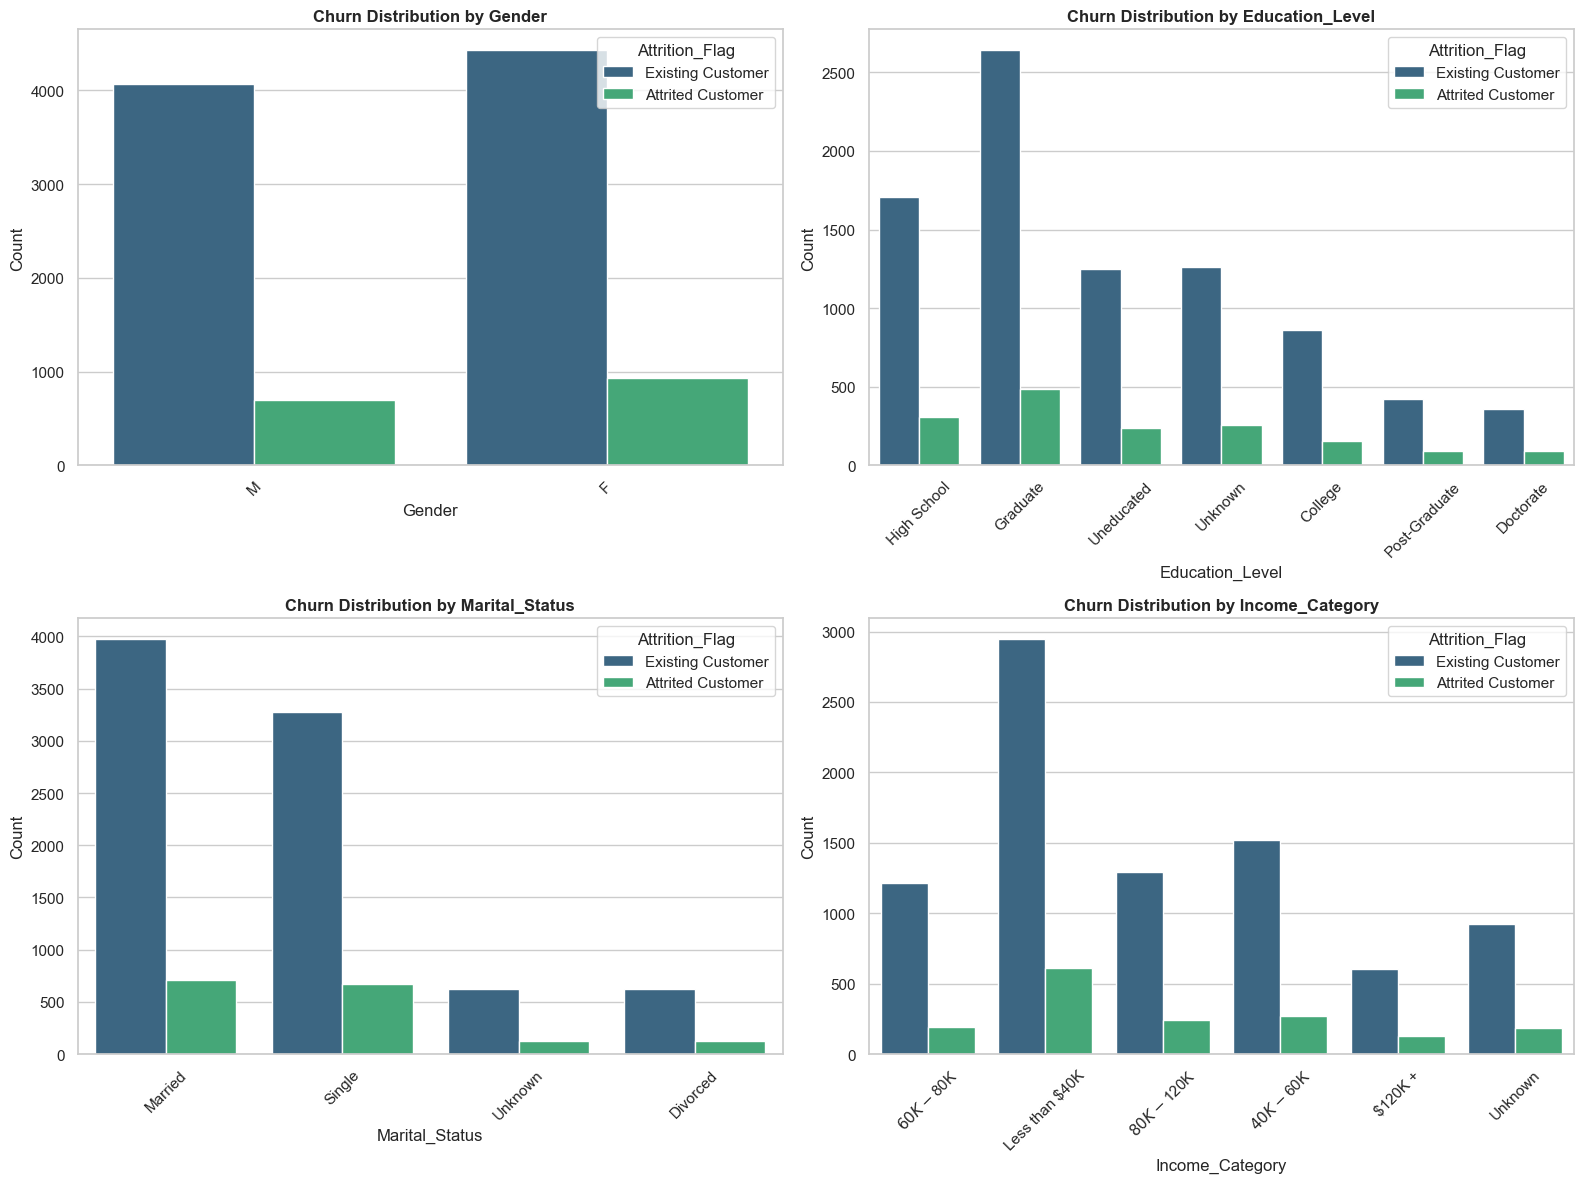

In [5]:
# Plot categorical features against Attrition_Flag
categorical_features = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, hue='Attrition_Flag', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Churn Distribution by {col}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_4436\819811097.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition_Flag', y='Total_Trans_Amt', palette='Set2', ax=axes[0])
C:\Users\Admin\AppData\Local\Temp\ipykernel_4436\819811097.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition_Flag', y='Total_Trans_Ct', palette='Set2', ax=axes[1])


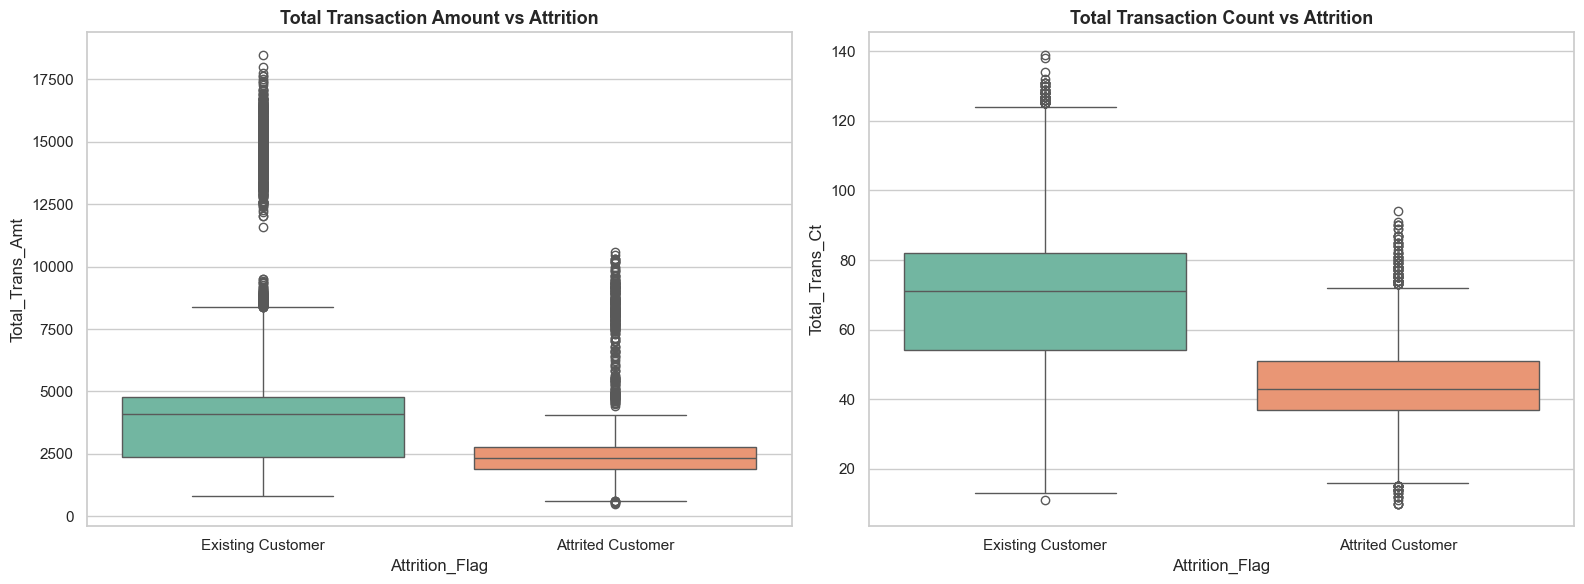

In [ ]:
# Visualize the relationship between Transaction Amount, Transaction Count and Churn
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot for total transaction amount
sns.boxplot(data=df, x='Attrition_Flag', y='Total_Trans_Amt', palette='Set2', ax=axes[0])
axes[0].set_title('Total Transaction Amount vs Attrition', fontsize=13, fontweight='bold')

# Boxplot for Total Transaction Count
sns.boxplot(data=df, x='Attrition_Flag', y='Total_Trans_Ct', palette='Set2', ax=axes[1])
axes[1].set_title('Total Transaction Count vs Attrition', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
# Attrited customers tend to have significantly lower transaction counts and amounts.

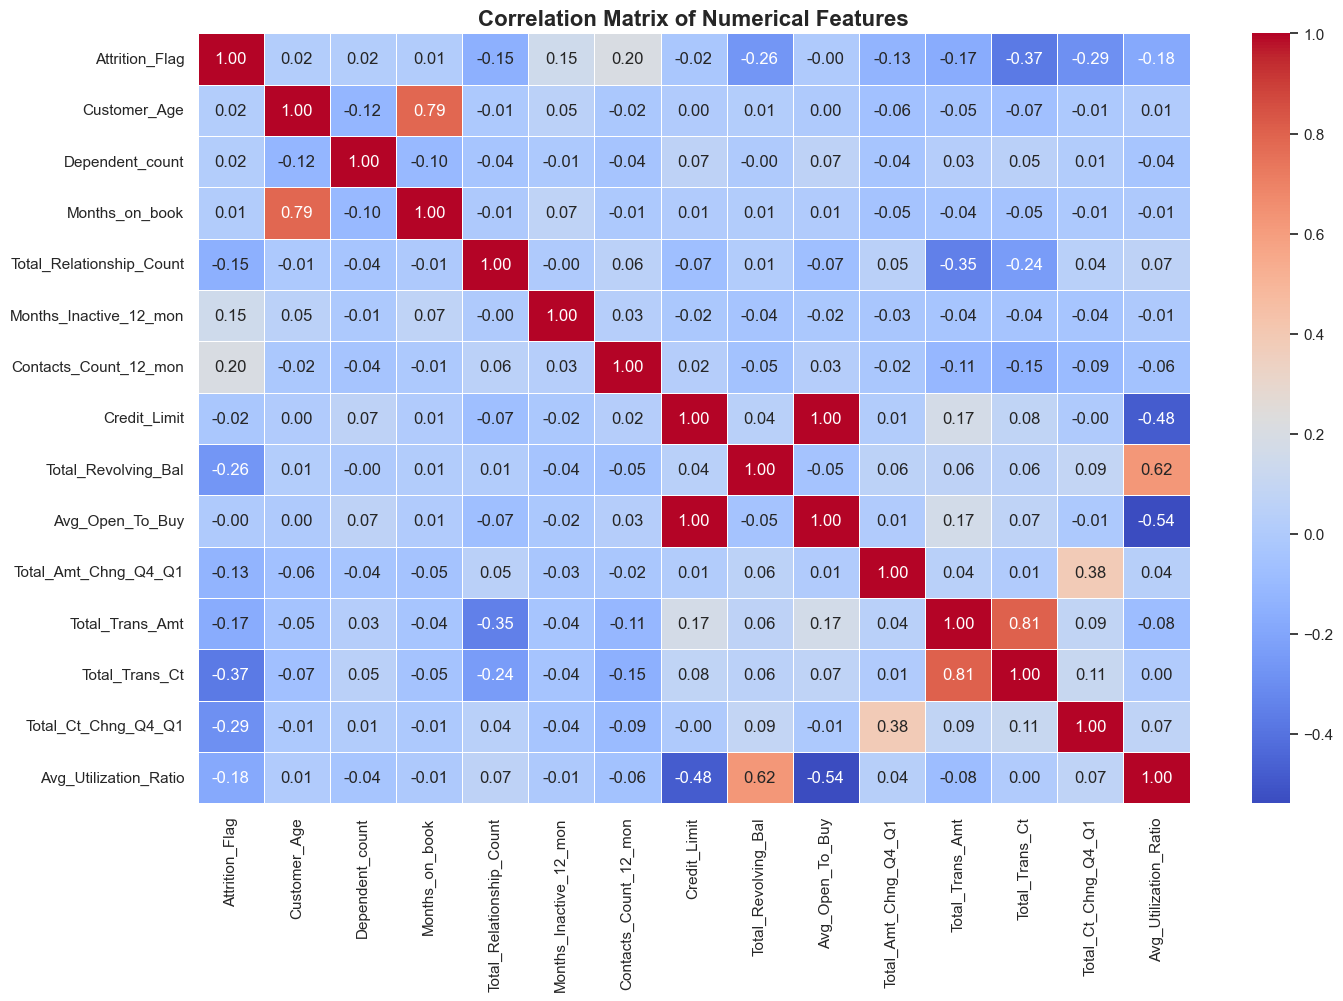

In [ ]:
# Create a heatmap to check multicollinearity among numerical variables
# encode the target variable temporarily for correlation
df_corr = df.copy()
df_corr['Attrition_Flag'] = df_corr['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)

# Select only numerical columns
numerical_cols = df_corr.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df_corr[numerical_cols].corr()

plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.show()